In [1]:
import sys
sys.path.append('..')

import uproot
import numpy as np
import pandas as pd
import seaborn as sns
import awkward as ak 
import matplotlib.pyplot as plt

from lariat import Event
from matplotlib.patches import Rectangle

In [ ]:
allclusters = pd.read_pickle("/Users/user/data/research/proton-deuteron/csv/allclusters.pkl")

In [76]:
allclusters = allclusters[allclusters['height']>1]
allclusters = allclusters[allclusters['column_maxes'].map(lambda x: len(set(x)) > 1)]
collection = (
    (allclusters['plane'] == 'collection') &
    (allclusters['bbox_min_row'] > 12) & (allclusters['bbox_min_row'] < 37) &
    (allclusters['bbox_max_col'] > 789) & (allclusters['bbox_max_col'] < 1927)
)

induction = (
    (allclusters['plane'] == 'induction') &
    (allclusters['bbox_min_row'] > 11) & (allclusters['bbox_min_row'] < 35) &
    (allclusters['bbox_max_col'] > 786) & (allclusters['bbox_max_col'] < 1794)
)

allclusters = allclusters[collection | induction].reset_index(drop=True); print(allclusters.shape)

(34817, 27)


In [77]:
allclusters[['run', 'subrun', 'event']].drop_duplicates().shape[0]

14439

In [78]:
coll = allclusters[allclusters['plane'] == 'collection']
ind = allclusters[allclusters['plane'] == 'induction']

In [79]:
coll

,event_idx,run,subrun,event,file_path,event_index,particle_type,plane,cluster_idx,area,...,bbox_min_col,bbox_max_row,bbox_max_col,width,height,aspect_ratio,compactness,image_intensity,matrix_transformed,column_maxes
0,0,8667,148,10828,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,collection,0,9047.0,...,154,196,944,790,171,4.619883,0.066970,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[16.0, -0.0, -0.0, 0.0, -0.0, -0.0, -0.0, 0.0...","[30.0, 99.0, 109.0, 78.0, 78.0, 80.0, 85.0, 78..."
2,1,8682,479,43081,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,collection,2,10122.0,...,1561,220,1825,264,193,1.367876,0.198658,"[[-0.0, -0.0, -0.0, -0.0, -0.0, 0.0, 0.0, -0.0...","[[-0.0, -0.0, 0.0, -0.0, -0.0, -0.0, -0.0, -0....","[43.0, 53.0, 77.0, 133.0, 66.0, 70.0, 72.0, 71..."
4,3,8599,28,2727,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,collection,0,910.0,...,894,44,1014,120,14,8.571429,0.541667,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[-0.0, 18.0, 0.0, -0.0, -0.0, 0.0, -0.0, 0.0,...","[29.0, 400.0, 363.0, 304.0, 308.0, 340.0, 325...."
6,4,8605,447,40174,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,collection,1,6715.0,...,608,138,1051,443,106,4.179245,0.143000,"[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[[16.0, -0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0.0, -...","[184.0, 183.0, 145.0, 143.0, 143.0, 153.0, 149..."
8,5,9509,427,41399,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,collection,4,10561.0,...,1574,229,1918,344,196,1.755102,0.156636,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, -0.0, 0.0, -0.0, -0.0, -0.0, ...","[33.0, 54.0, 57.0, 57.0, 64.0, 55.0, 58.0, 94...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34808,7632,9788,299,26208,/Users/user/data/research/proton-deuteron/rawp...,0,proton,collection,1,3000.0,...,1095,74,1279,184,53,3.471698,0.307629,"[[-0.0, 0.0, -0.0, 0.0, 0.0, 0.0, -0.0, 0.0, -...","[[16.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0, 0.0...","[20.0, 46.0, 90.0, 71.0, 80.0, 98.0, 87.0, 99...."
34810,7633,9788,305,26707,/Users/user/data/research/proton-deuteron/rawp...,0,proton,collection,0,165.0,...,1645,21,1787,142,2,71.000000,0.580986,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 16.0], [0.0, 16.0], [0.0, 17.0], [0.0, ...","[23.0, 60.0]"
34811,7633,9788,305,26707,/Users/user/data/research/proton-deuteron/rawp...,0,proton,collection,1,1079.0,...,883,52,1043,160,20,8.000000,0.337187,"[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[[17.0, -0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0.0, -...","[62.0, 115.0, 136.0, 101.0, 99.0, 104.0, 81.0,..."
34813,7634,9788,308,26943,/Users/user/data/research/proton-deuteron/rawp...,0,proton,collection,0,2692.0,...,906,71,1052,146,45,3.244444,0.409741,"[[-0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...","[[17.0, -0.0, 0.0, -0.0, -0.0, -0.0, 0.0, -0.0...","[55.0, 81.0, 87.0, 144.0, 131.0, 120.0, 122.0,..."


In [80]:
ind

,event_idx,run,subrun,event,file_path,event_index,particle_type,plane,cluster_idx,area,...,bbox_min_col,bbox_max_row,bbox_max_col,width,height,aspect_ratio,compactness,image_intensity,matrix_transformed,column_maxes
1,0,8667,148,10828,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,induction,0,4030.0,...,156,169,873,717,148,4.844595,0.037977,"[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[[17.0, 0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....","[20.0, 78.0, 66.0, 55.0, 47.0, 43.0, 47.0, 48...."
3,1,8682,479,43081,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,induction,0,3461.0,...,1617,162,1717,100,142,0.704225,0.243732,"[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[[16.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[21.0, 38.0, 80.0, 53.0, 50.0, 46.0, 47.0, 44...."
5,3,8599,28,2727,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,induction,0,530.0,...,856,29,956,100,13,7.692308,0.407692,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[19.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[105.0, 228.0, 205.0, 185.0, 171.0, 168.0, 198..."
7,4,8605,447,40174,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,induction,1,3545.0,...,566,121,958,392,105,3.733333,0.086127,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[16.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[49.0, 82.0, 93.0, 90.0, 107.0, 85.0, 95.0, 78..."
11,6,9566,93,8335,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,induction,1,478.0,...,1117,37,1201,84,12,7.000000,0.474206,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[17.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[91.0, 184.0, 175.0, 184.0, 198.0, 195.0, 189...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34807,7631,9788,297,26027,/Users/user/data/research/proton-deuteron/rawp...,0,proton,induction,0,1550.0,...,755,63,970,215,51,4.215686,0.141359,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[17.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[27.0, 60.0, 71.0, 73.0, 78.0, 75.0, 81.0, 73...."
34809,7632,9788,299,26208,/Users/user/data/research/proton-deuteron/rawp...,0,proton,induction,0,1456.0,...,1079,76,1222,143,52,2.750000,0.195804,"[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[[16.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[24.0, 60.0, 59.0, 58.0, 69.0, 53.0, 52.0, 55...."
34812,7633,9788,305,26707,/Users/user/data/research/proton-deuteron/rawp...,0,proton,induction,0,534.0,...,870,33,962,92,20,4.600000,0.290217,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[16.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[19.0, 60.0, 70.0, 51.0, 52.0, 54.0, 52.0, 52...."
34814,7634,9788,308,26943,/Users/user/data/research/proton-deuteron/rawp...,0,proton,induction,0,1359.0,...,891,66,997,106,47,2.255319,0.272782,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[16.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[17.0, 50.0, 67.0, 77.0, 68.0, 65.0, 67.0, 73...."


In [81]:
row = allclusters.query('run == 8667 & subrun == 148 & event == 10828')
row

,event_idx,run,subrun,event,file_path,event_index,particle_type,plane,cluster_idx,area,...,bbox_min_col,bbox_max_row,bbox_max_col,width,height,aspect_ratio,compactness,image_intensity,matrix_transformed,column_maxes
0,0,8667,148,10828,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,collection,0,9047.0,...,154,196,944,790,171,4.619883,0.066970,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[16.0, -0.0, -0.0, 0.0, -0.0, -0.0, -0.0, 0.0...","[30.0, 99.0, 109.0, 78.0, 78.0, 80.0, 85.0, 78..."
1,0,8667,148,10828,/Users/user/data/research/proton-deuteron/rawd...,0,deuteron,induction,0,4030.0,...,156,169,873,717,148,4.844595,0.037977,"[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[[17.0, 0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0....","[20.0, 78.0, 66.0, 55.0, 47.0, 43.0, 47.0, 48...."


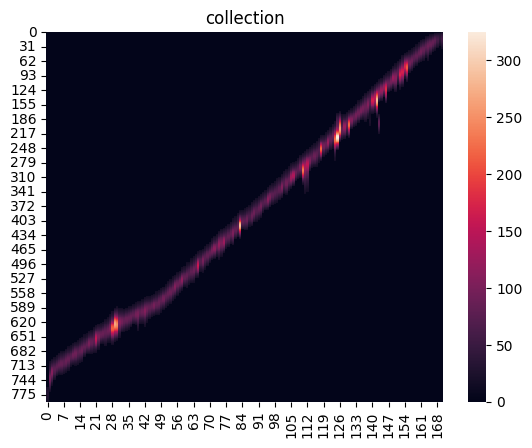

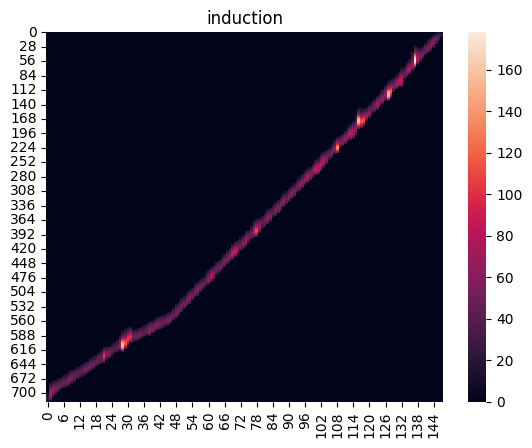

In [82]:
for idx, r in row.iterrows():
    sns.heatmap(r['image_intensity'].T)
    plt.title(f"{r['plane']}")
    plt.show()

In [57]:
c = coll.query('run == 8682 & subrun == 479 & event == 43081')

In [58]:
i = ind.query('run == 8682 & subrun == 479 & event == 43081')

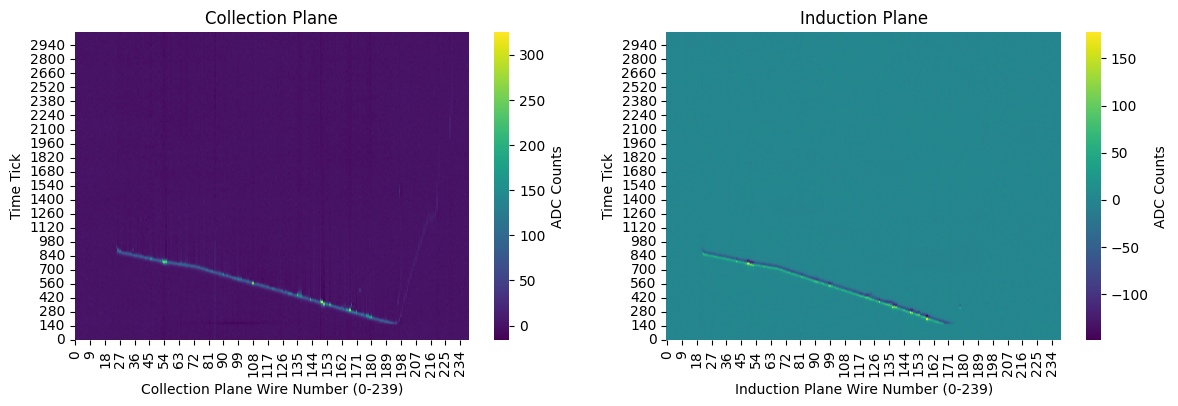

In [59]:
event = Event(row.iloc[0]['file_path'], row.iloc[0]['event_index'], threshold=15)

In [41]:
allclusters.columns

Index(['event_idx', 'run', 'subrun', 'event', 'file_path', 'event_index',
       'particle_type', 'plane', 'cluster_idx', 'area', 'max_intensity',
       'min_intensity', 'mean_intensity', 'total_intensity', 'centroid_x',
       'centroid_y', 'bbox_min_row', 'bbox_min_col', 'bbox_max_row',
       'bbox_max_col', 'width', 'height', 'aspect_ratio', 'compactness',
       'image_intensity', 'matrix_transformed', 'column_maxes'],
      dtype='object')

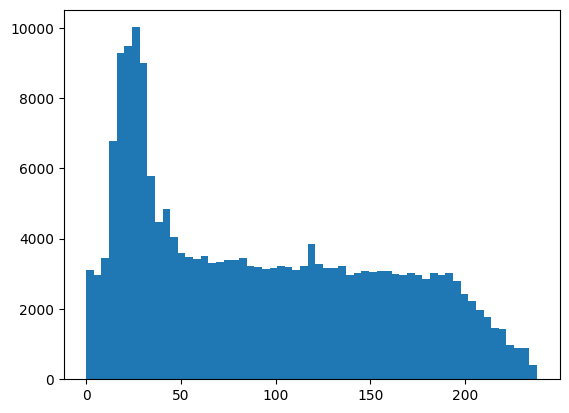

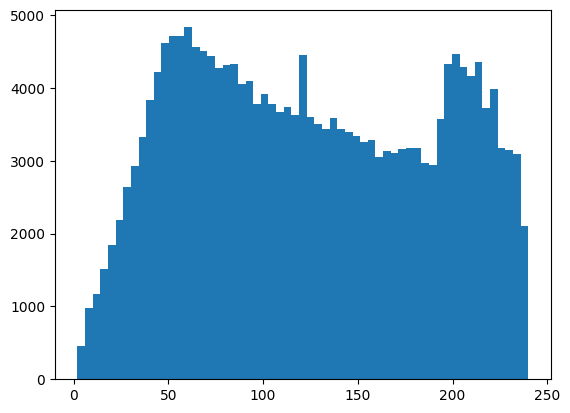

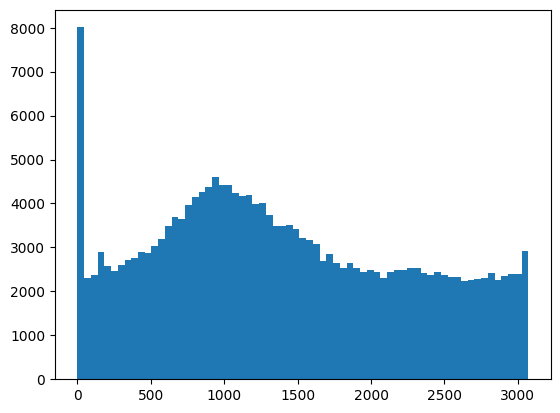

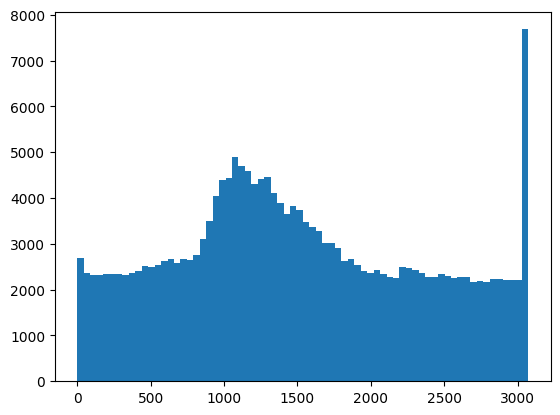

In [52]:
plt.hist(allclusters['bbox_min_row'], bins=59); plt.show()
plt.hist(allclusters['bbox_max_row'], bins=59); plt.show()
plt.hist(allclusters['bbox_min_col'], bins='auto'); plt.show()
plt.hist(allclusters['bbox_max_col'], bins='auto'); plt.show()

In [83]:
import pandas as pd
import numpy as np

def _plane_masks(df):
    """Return boolean masks for induction and collection planes, handling strings or ints."""
    if df['plane'].dtype == object:
        pl = df['plane'].str.lower()
        induction_mask = pl.str.contains('induction')
        collection_mask = pl.str.contains('collection')
    else:
        # Common convention in LArTPC: 0/1 = induction, 2 = collection
        induction_mask  = df['plane'].isin([0, 1])
        collection_mask = df['plane'].eq(2)
    return induction_mask, collection_mask

def pair_clusters(df,
                  col_delta_lo=25, col_delta_hi=75,
                  row_tol=15,
                  one_to_one=False):
    """
    Pair clusters across planes per event where:
      - same (run, subrun, event)
      - collection bbox_min_col and bbox_max_col are 25–75 *greater than* induction’s
      - bbox rows within ±15
    Params allow you to tweak those thresholds.
    """
    keys = ['run', 'subrun', 'event']  # adjust if your primary keys are named differently
    for k in keys:
        if k not in df.columns:
            raise ValueError(f"Missing required key column: {k}")

    req = ['bbox_min_row','bbox_max_row','bbox_min_col','bbox_max_col','cluster_idx','plane']
    missing = [c for c in req if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    ind_mask, col_mask = _plane_masks(df)
    ind = df.loc[ind_mask,  keys + ['cluster_idx','bbox_min_row','bbox_max_row','bbox_min_col','bbox_max_col']].copy()
    col = df.loc[col_mask,  keys + ['cluster_idx','bbox_min_row','bbox_max_row','bbox_min_col','bbox_max_col']].copy()

    ind = ind.rename(columns={
        'cluster_idx':'cluster_idx_ind',
        'bbox_min_row':'ind_min_r','bbox_max_row':'ind_max_r',
        'bbox_min_col':'ind_min_c','bbox_max_col':'ind_max_c'
    })
    col = col.rename(columns={
        'cluster_idx':'cluster_idx_col',
        'bbox_min_row':'col_min_r','bbox_max_row':'col_max_r',
        'bbox_min_col':'col_min_c','bbox_max_col':'col_max_c'
    })

    # Candidate pairs: inner join on (run, subrun, event)
    pairs = ind.merge(col, on=keys, how='inner')

    # Deltas
    pairs['d_min_c'] = pairs['col_min_c'] - pairs['ind_min_c']
    pairs['d_max_c'] = pairs['col_max_c'] - pairs['ind_max_c']
    pairs['d_min_r'] = pairs['col_min_r'] - pairs['ind_min_r']
    pairs['d_max_r'] = pairs['col_max_r'] - pairs['ind_max_r']

    # Apply your rule
    cond = (
        (pairs['d_min_c'].between(col_delta_lo, col_delta_hi)) &
        (pairs['d_max_c'].between(col_delta_lo, col_delta_hi)) &
        (pairs['d_min_r'].abs() <= row_tol) &
        (pairs['d_max_r'].abs() <= row_tol)
    )
    candidates = pairs.loc[cond].copy()

    # A simple score: smaller is "tighter" alignment
    # Mix column-gap closeness and row agreement
    target_mid = (col_delta_lo + col_delta_hi) / 2.0
    col_score = (pairs.loc[cond, ['d_min_c','d_max_c']] - target_mid).pow(2).sum(axis=1)
    row_score = pairs.loc[cond, ['d_min_r','d_max_r']].pow(2).sum(axis=1)
    candidates['match_score'] = (col_score + row_score).astype(float)

    # Sort for readability
    candidates = candidates.sort_values(keys + ['match_score',
                                                'cluster_idx_ind','cluster_idx_col']).reset_index(drop=True)

    if not one_to_one:
        # Return all valid pairs (many-to-many possible)
        return candidates[keys + [
            'cluster_idx_ind','cluster_idx_col',
            'ind_min_r','ind_max_r','ind_min_c','ind_max_c',
            'col_min_r','col_max_r','col_min_c','col_max_c',
            'd_min_c','d_max_c','d_min_r','d_max_r','match_score'
        ]]

    # Optional greedy 1-1 per event: pick lowest score first, then drop conflicts
    def _greedy_one_to_one(group):
        g = group.sort_values('match_score').copy()
        used_ind = set()
        used_col = set()
        keep = []
        for _, row in g.iterrows():
            i = row['cluster_idx_ind']
            c = row['cluster_idx_col']
            if i not in used_ind and c not in used_col:
                keep.append(True)
                used_ind.add(i)
                used_col.add(c)
            else:
                keep.append(False)
        return g.loc[keep]

    one2one = (
        candidates
        .groupby(keys, group_keys=False)
        .apply(_greedy_one_to_one)
        .reset_index(drop=True)
    )

    return one2one[keys + [
        'cluster_idx_ind','cluster_idx_col',
        'd_min_c','d_max_c','d_min_r','d_max_r','match_score'
    ]]

# Example usage:
# pairs_all = pair_clusters(df, one_to_one=False)
pairs_1to1 = pair_clusters(allclusters, one_to_one=True)


/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_48886/2697459255.py:110: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_greedy_one_to_one)


In [84]:
pairs_1to1

,run,subrun,event,cluster_idx_ind,cluster_idx_col,d_min_c,d_max_c,d_min_r,d_max_r,match_score
0,8557,4,473,0,0,41,68,12,15,774.0
1,8557,9,700,0,0,25,61,6,3,791.0
2,8557,10,734,0,0,31,69,2,6,762.0
3,8557,33,1749,0,3,28,51,-4,-8,565.0
4,8557,52,2635,0,0,29,72,10,10,1125.0
...,...,...,...,...,...,...,...,...,...,...
2838,9788,185,16103,0,0,30,44,7,-3,494.0
2839,9788,212,18790,1,0,58,61,13,14,550.0
2840,9788,239,21106,2,0,39,48,-8,0,189.0
2841,9788,270,23699,0,0,25,64,-15,-13,1215.0


/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_48886/2697459255.py:110: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_greedy_one_to_one)


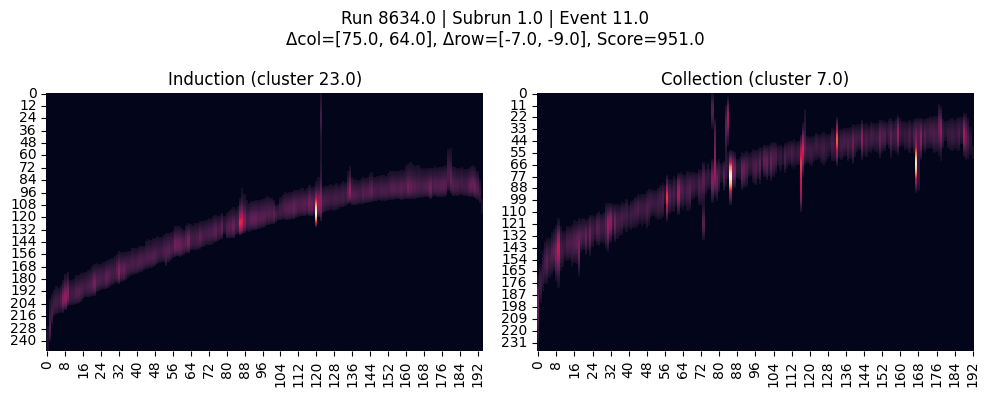

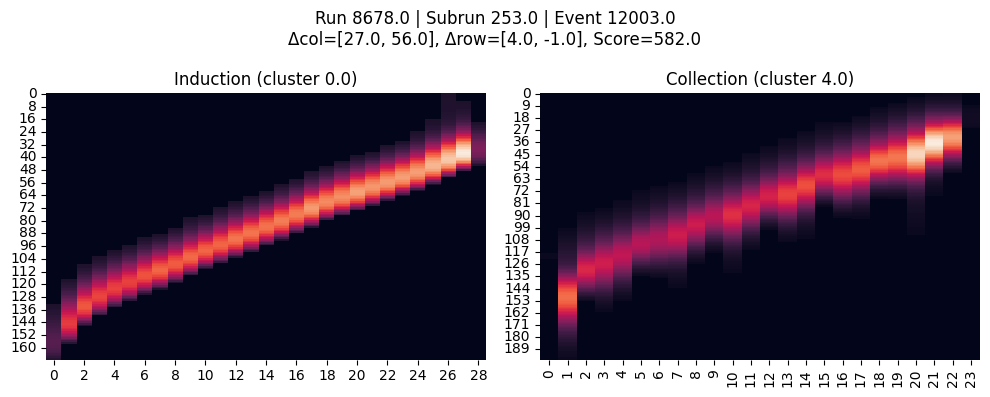

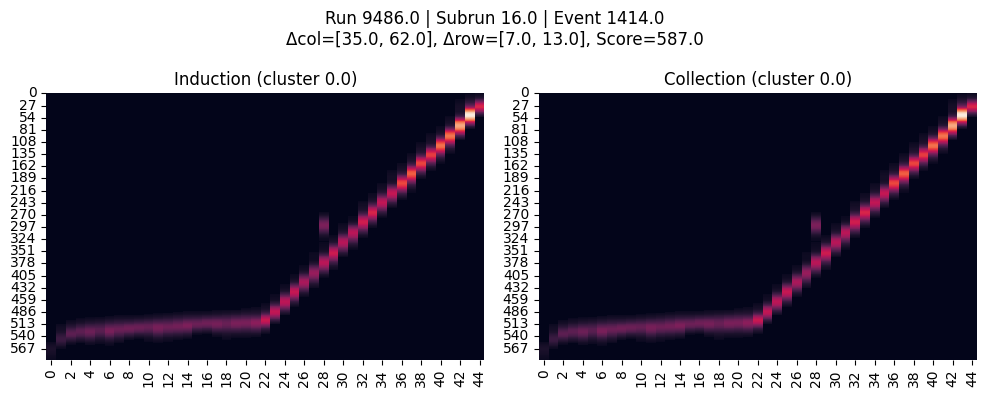

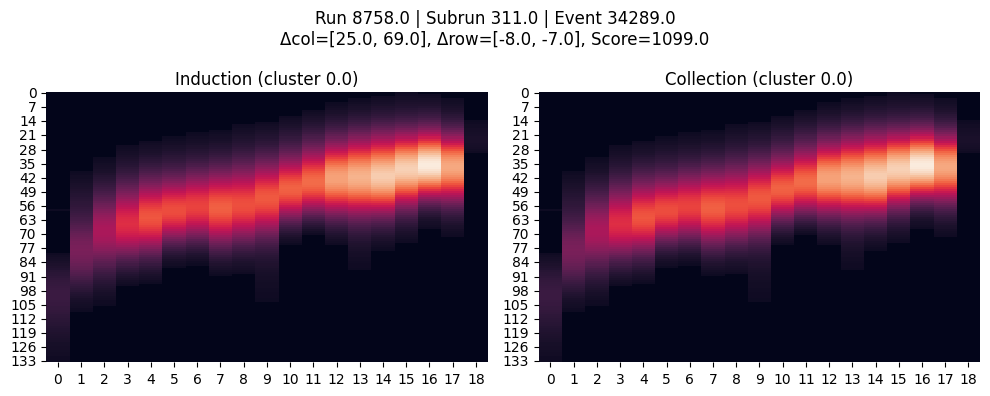

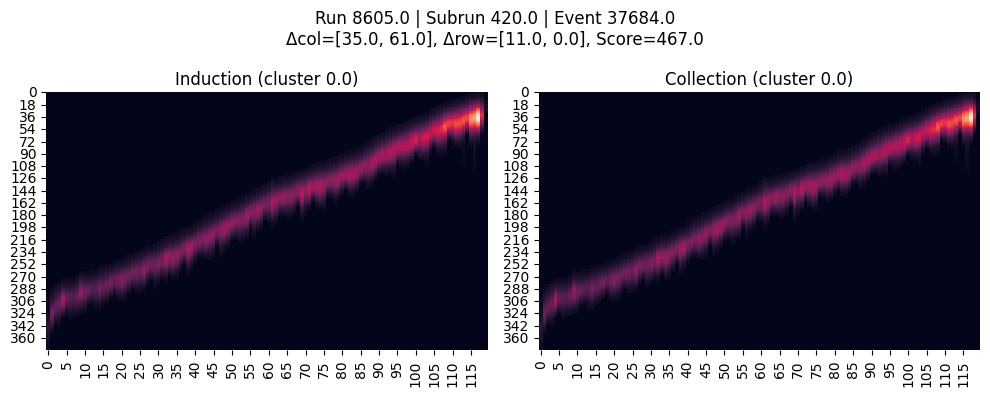

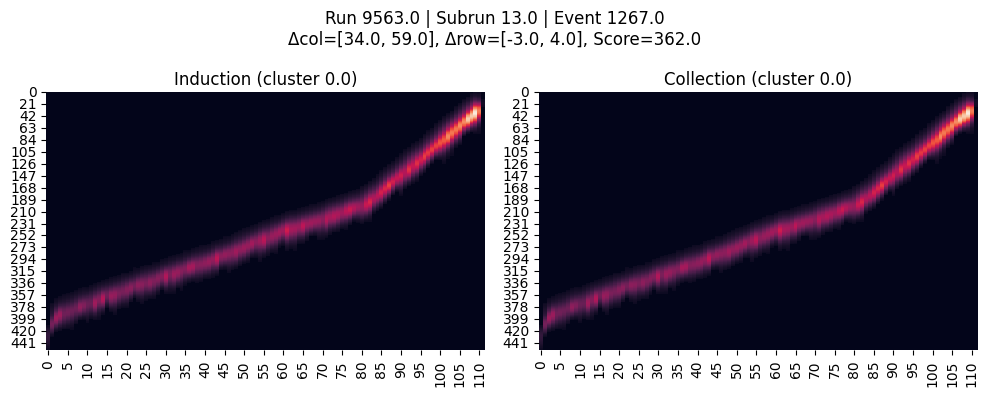

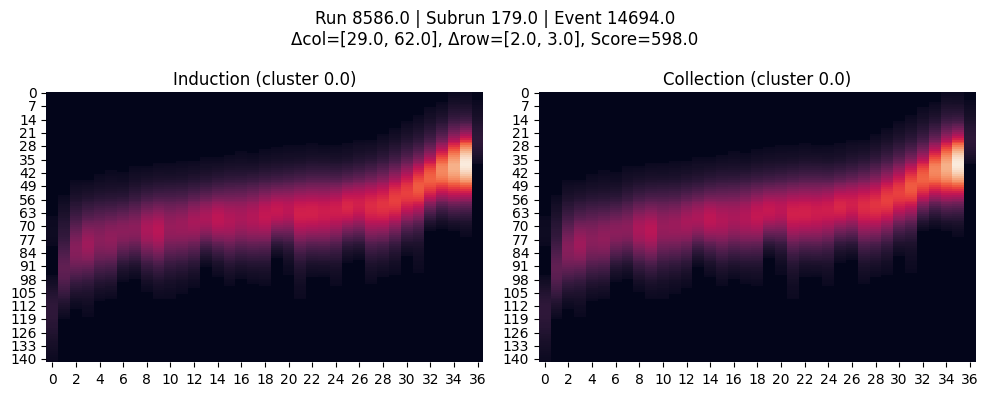

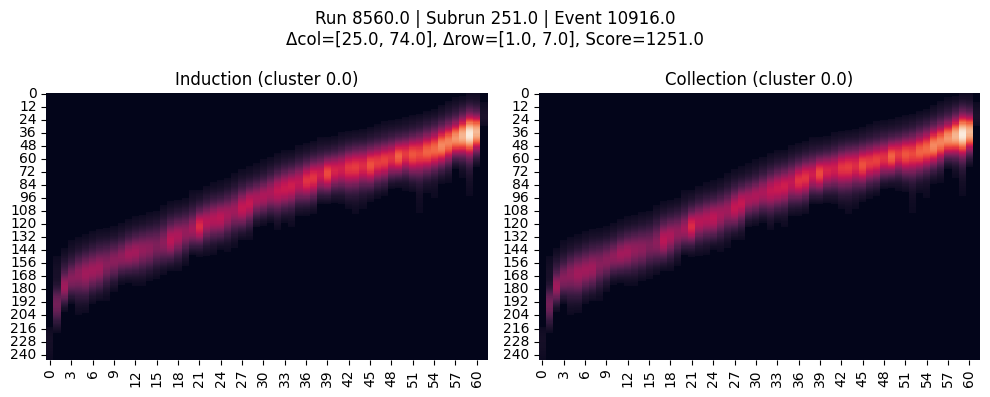

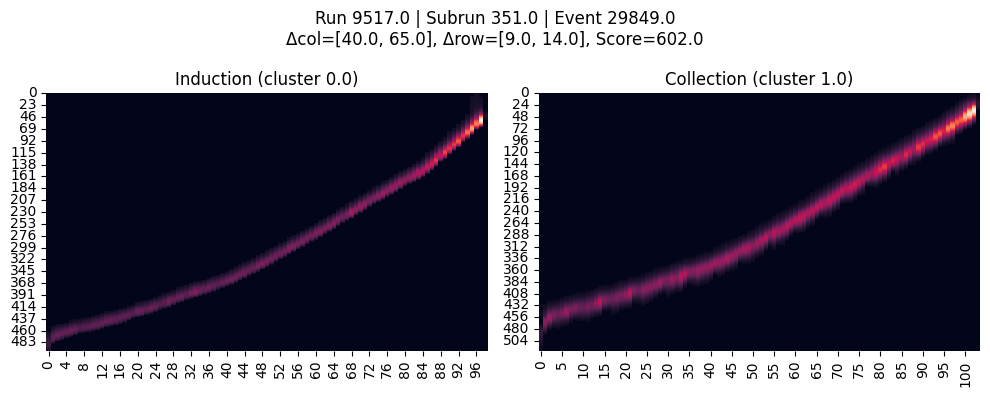

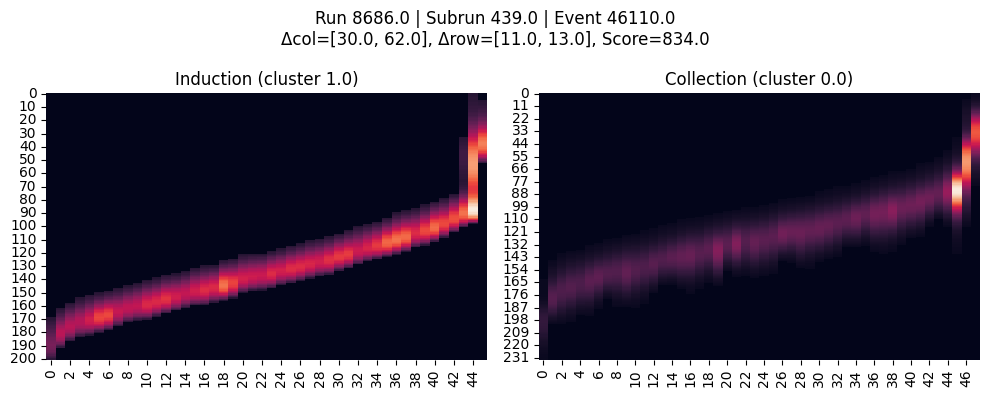

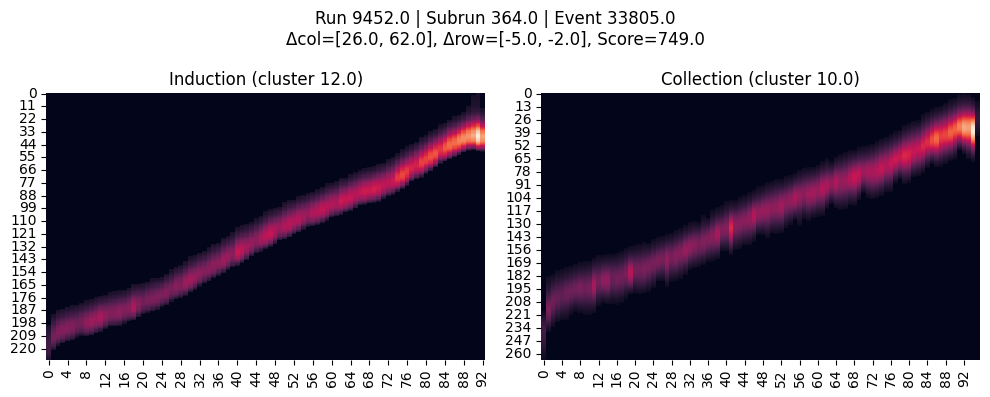

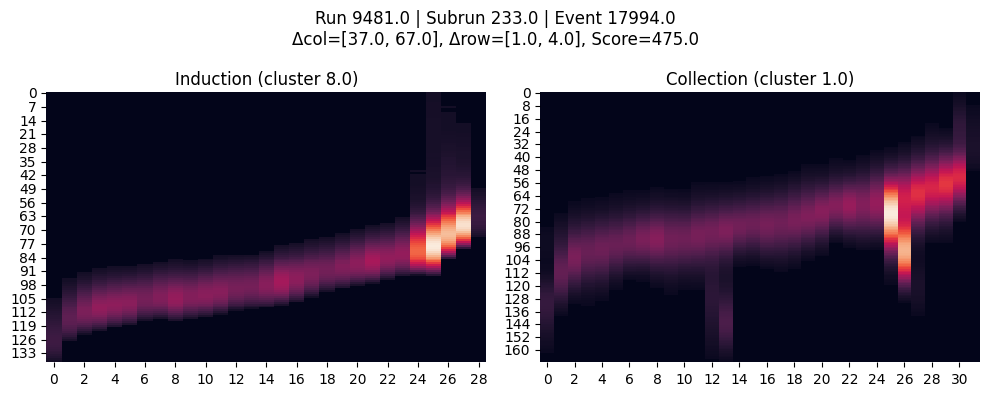

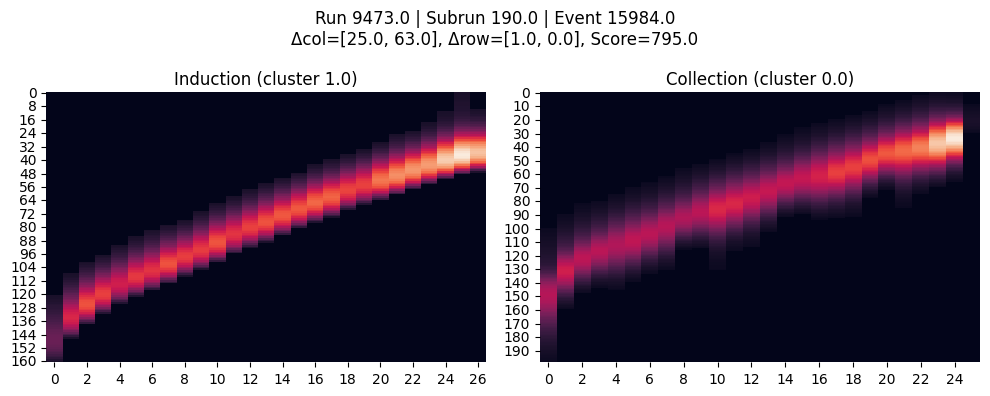

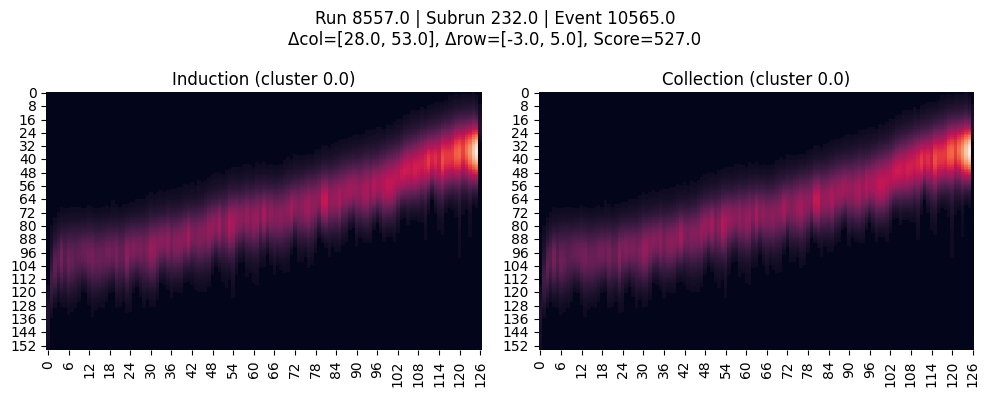

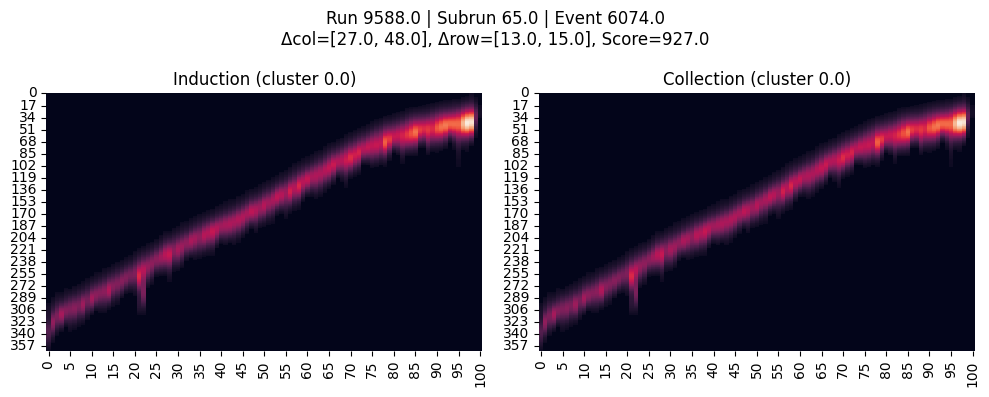

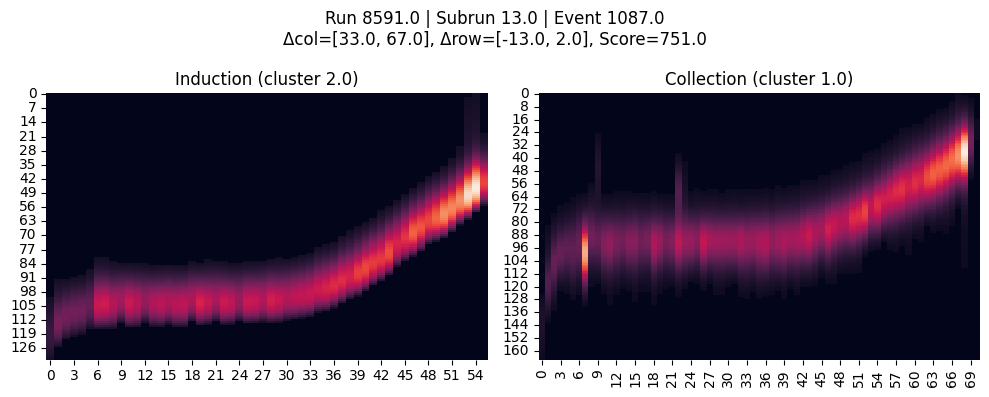

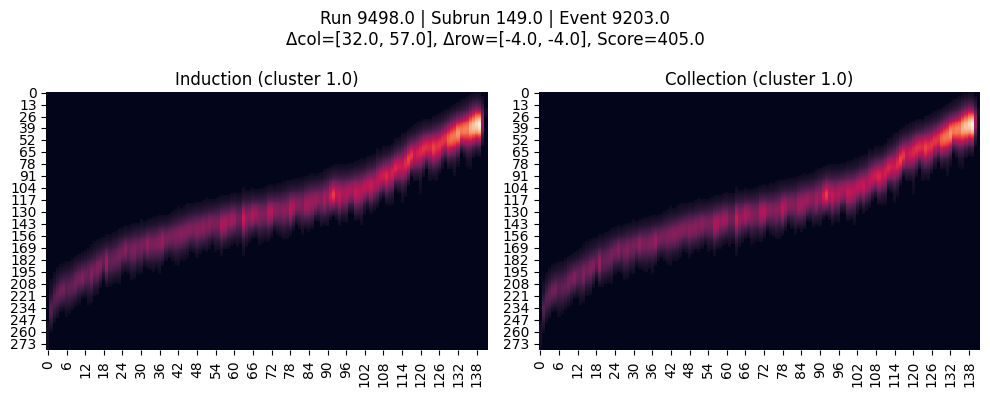

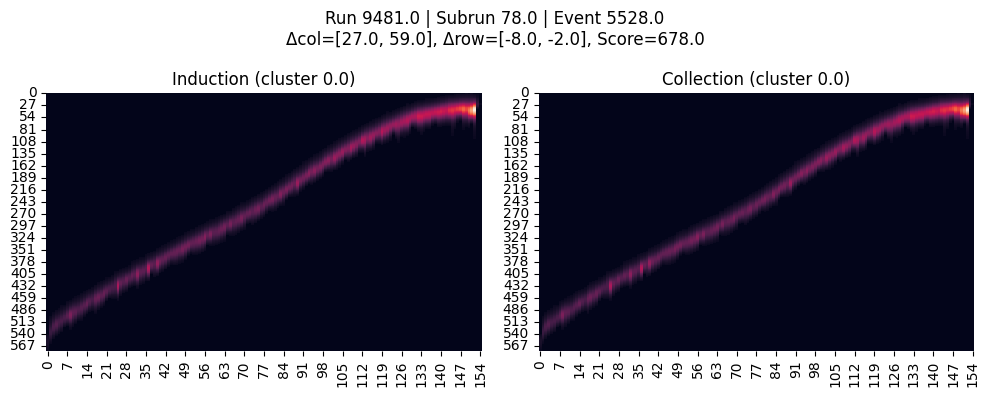

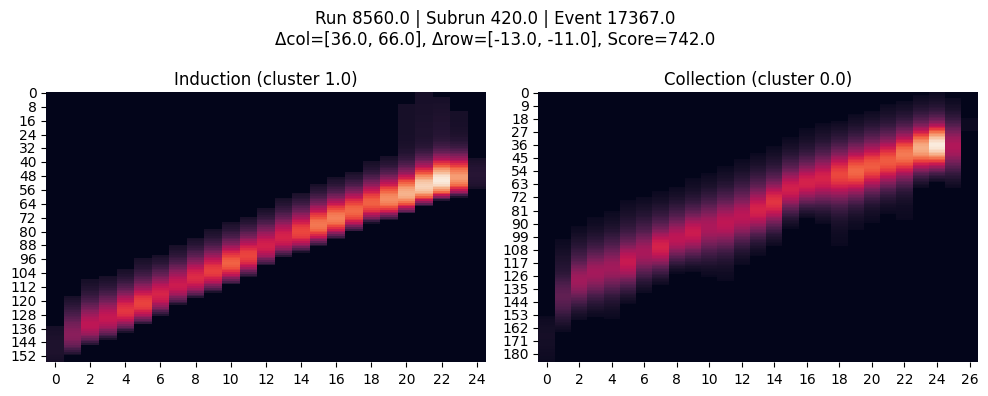

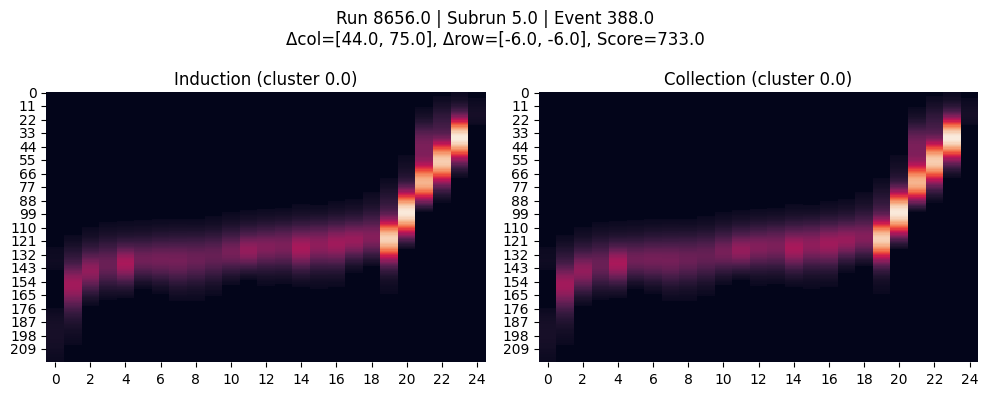

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_random_cluster_pairs(df, pairs, n_samples=5, random_state=None):
    """
    Randomly pick matched cluster pairs and plot induction vs collection side by side.
    
    df: full cluster DataFrame (with 'image_intensity' & 'plane')
    pairs: output of pair_clusters()
    n_samples: number of random pairs to plot
    random_state: set for reproducibility
    """
    if len(pairs) == 0:
        print("No pairs to plot.")
        return
    
    sample_pairs = pairs.sample(n=min(n_samples, len(pairs)), 
                                random_state=random_state)
    
    for _, pair in sample_pairs.iterrows():
        # Select the corresponding clusters
        ind = df[(df['cluster_idx'] == pair['cluster_idx_ind']) &
                 (df['event'] == pair['event']) &
                 (df['subrun'] == pair['subrun']) &
                 (df['run'] == pair['run'])]
        col = df[(df['cluster_idx'] == pair['cluster_idx_col']) &
                 (df['event'] == pair['event']) &
                 (df['subrun'] == pair['subrun']) &
                 (df['subrun'] == pair['subrun'])]

        if ind.empty or col.empty:
            continue
        
        ind_row = ind.iloc[0]
        col_row = col.iloc[0]

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        
        sns.heatmap(ind_row['image_intensity'].T, ax=axes[0], cbar=False)
        axes[0].set_title(f"Induction (cluster {pair['cluster_idx_ind']})")

        sns.heatmap(col_row['image_intensity'].T, ax=axes[1], cbar=False)
        axes[1].set_title(f"Collection (cluster {pair['cluster_idx_col']})")

        fig.suptitle(
            f"Run {pair['run']} | Subrun {pair['subrun']} | Event {pair['event']}\n"
            f"Δcol=[{pair['d_min_c']:.1f}, {pair['d_max_c']:.1f}], "
            f"Δrow=[{pair['d_min_r']:.1f}, {pair['d_max_r']:.1f}], "
            f"Score={pair['match_score']:.1f}"
        )
        
        plt.tight_layout()
        plt.show()

# Example:
pairs = pair_clusters(allclusters, one_to_one=True)
plot_random_cluster_pairs(allclusters, pairs, n_samples=20, random_state=None)
